# Train and compare: ElasticNet, KNN, XGBoost

Same flow as `pricing_lab/run_all.py`: Optuna tuning on the log target, then test-set metrics in dollars. Adjust paths and trial counts in the next cells.

In [6]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

def ensure_project_root() -> Path:
    """Put the repo root on sys.path so `import pricing_lab` works without pip install."""
    cwd = Path.cwd().resolve()
    for root in (cwd, *cwd.parents):
        if (root / "pricing_lab" / "__init__.py").is_file():
            s = str(root)
            if s not in sys.path:
                sys.path.insert(0, s)
            return root
    raise RuntimeError(
        "Could not find project root (folder containing pricing_lab). "
        "Open/run this notebook from the BNB_Pricing repo or set PYTHONPATH."
    )


!python --version

PROJECT_ROOT = ensure_project_root()
print("Project root:", PROJECT_ROOT)

Python 3.12.13
Project root: /Users/Kushal/Projects/BNB_Pricing


In [2]:
# Configure all runtime overrides here before running the training cell.
# Set to a CSV path string, or None for `pricing_lab.config.DATA_PATH`
CSV_PATH = None
# Training mode: sample (fast) or full (heavier search)
MODE = "full"
# Optional overrides for Optuna trials (None = use mode defaults)
N_TRIALS_ELASTIC = None
N_TRIALS_KNN = None
N_TRIALS_XGB = None
# Optional: save summary table to CSV (string path) or None to skip
OUTPUT_CSV = None
# Save fitted model artifacts (.joblib)
SAVE_MODELS = True
MODEL_OUTPUT_DIR = "artifacts"

In [3]:
import json
import warnings
from typing import Any

import optuna
import pandas as pd
from IPython.display import display
from joblib import dump
from sklearn.exceptions import ConvergenceWarning

from pricing_lab import config
from pricing_lab.data import TrainTestData, load_train_test
from pricing_lab.models.elastic_net import ElasticNetResult, tune_elastic_net
from pricing_lab.models.knn import KnnResult, tune_knn
from pricing_lab.models.xgboost_model import XgboostResult, tune_xgboost

SAMPLE_TRAIN_FRACTION = 0.35
SAMPLE_TRIALS_ELASTIC = 10
SAMPLE_TRIALS_KNN = 6
SAMPLE_TRIALS_XGB = 14

# Resolve the dataset path first so all models use the same input split.
resolved = config.DATA_PATH if CSV_PATH is None else Path(CSV_PATH)
print("Using CSV:", resolved)

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

full_data: TrainTestData = load_train_test(csv_path=str(CSV_PATH) if CSV_PATH is not None else None)
print(f"Mode: {MODE}", flush=True)
print(f"Train rows: {len(full_data.X_train)}, test rows: {len(full_data.X_test)}", flush=True)

if MODE not in {"sample", "full"}:
    raise ValueError("MODE must be 'sample' or 'full'.")

if MODE == "sample":
    sampled_features = full_data.X_train.sample(frac=SAMPLE_TRAIN_FRACTION, random_state=config.RANDOM_STATE)
    sampled_target = full_data.y_train.loc[sampled_features.index]
    data = TrainTestData(
        X_train=sampled_features.reset_index(drop=True),
        X_test=full_data.X_test,
        y_train=sampled_target.reset_index(drop=True),
        y_test=full_data.y_test,
    )
    print(
        f"Sample mode: using {len(data.X_train)} / {len(full_data.X_train)} train rows "
        f"({SAMPLE_TRAIN_FRACTION:.0%}) for Optuna + fit.",
        flush=True,
    )
else:
    data = full_data

elastic_trials = N_TRIALS_ELASTIC if N_TRIALS_ELASTIC is not None else (
    SAMPLE_TRIALS_ELASTIC if MODE == "sample" else config.N_TRIALS_ELASTICNET
)
knn_trials = N_TRIALS_KNN if N_TRIALS_KNN is not None else (
    SAMPLE_TRIALS_KNN if MODE == "sample" else config.N_TRIALS_KNN
)
xgb_trials = N_TRIALS_XGB if N_TRIALS_XGB is not None else (
    SAMPLE_TRIALS_XGB if MODE == "sample" else config.N_TRIALS_XGBOOST
)
print(f"Trials => ElasticNet: {elastic_trials}, KNN: {knn_trials}, XGBoost: {xgb_trials}", flush=True)

print("Tuning ElasticNet...", flush=True)
elastic_result: ElasticNetResult = tune_elastic_net(data, n_trials=elastic_trials)
print("Tuning KNN...", flush=True)
knn_result: KnnResult = tune_knn(data, n_trials=knn_trials)
print("Tuning XGBoost...", flush=True)
xgb_result: XgboostResult = tune_xgboost(data, n_trials=xgb_trials)


def result_row(
    name: str,
    best_cv_rmse_log: float,
    test_mae: float,
    test_rmse: float,
    test_r2: float,
    best_params: dict[str, Any],
) -> dict[str, Any]:
    return {
        "model": name,
        "cv_rmse_log": round(best_cv_rmse_log, 6),
        "test_mae_dollars": round(test_mae, 4),
        "test_rmse_dollars": round(test_rmse, 4),
        "test_r2": round(test_r2, 6),
        "best_params_json": json.dumps(best_params, sort_keys=True),
    }


rows: list[dict[str, Any]] = [
    result_row(
        elastic_result.name,
        elastic_result.best_cv_rmse_log,
        elastic_result.test_metrics["mae"],
        elastic_result.test_metrics["rmse"],
        elastic_result.test_metrics["r2"],
        elastic_result.best_params,
    ),
    result_row(
        knn_result.name,
        knn_result.best_cv_rmse_log,
        knn_result.test_metrics["mae"],
        knn_result.test_metrics["rmse"],
        knn_result.test_metrics["r2"],
        knn_result.best_params,
    ),
    result_row(
        xgb_result.name,
        xgb_result.best_cv_rmse_log,
        xgb_result.test_metrics["mae"],
        xgb_result.test_metrics["rmse"],
        xgb_result.test_metrics["r2"],
        xgb_result.best_params,
    ),
]
# Show comparison table before optional writes.
table = pd.DataFrame(rows)
display(table)
print(table.to_string(index=False), flush=True)

if OUTPUT_CSV is not None:
    table.to_csv(OUTPUT_CSV, index=False)
    print(f"Wrote {OUTPUT_CSV}", flush=True)

if SAVE_MODELS:
    model_output_path = PROJECT_ROOT / MODEL_OUTPUT_DIR
    model_output_path.mkdir(parents=True, exist_ok=True)
    elastic_path = model_output_path / "elastic_net.joblib"
    knn_path = model_output_path / "knn.joblib"
    xgb_path = model_output_path / "xgboost.joblib"
    dump(elastic_result.pipeline, elastic_path)
    dump(knn_result.pipeline, knn_path)
    dump(xgb_result.pipeline, xgb_path)
    print(f"Wrote {elastic_path}", flush=True)
    print(f"Wrote {knn_path}", flush=True)
    print(f"Wrote {xgb_path}", flush=True)

Using CSV: /Users/Kushal/Projects/BNB_Pricing/AB_NYC_2019.csv
Mode: full
Train rows: 36700, test rows: 9176
Trials => ElasticNet: 35, KNN: 30, XGBoost: 45
Tuning ElasticNet...
Tuning KNN...
Tuning XGBoost...


,model,cv_rmse_log,test_mae_dollars,test_rmse_dollars,test_r2,best_params_json
0,ElasticNet,0.367063,32.9546,46.9603,0.513512,"{""alpha"": 0.0008123019592628809, ""l1_ratio"": 0..."
1,KNN,0.354630,31.6300,45.1741,0.549815,"{""leaf_size"": 50, ""n_neighbors"": 22, ""p"": 1, ""..."
2,XGBoost,0.336996,30.1947,43.5573,0.581464,"{""colsample_bytree"": 0.6849356442713105, ""gamm..."


     model  cv_rmse_log  test_mae_dollars  test_rmse_dollars  test_r2                                                                                                                                                                                                                                                                                        best_params_json
ElasticNet     0.367063           32.9546            46.9603 0.513512                                                                                                                                                                                                                      {"alpha": 0.0008123019592628809, "l1_ratio": 0.6827554091109473, "max_iter": 7000}
       KNN     0.354630           31.6300            45.1741 0.549815                                                                                                                                                                                                       

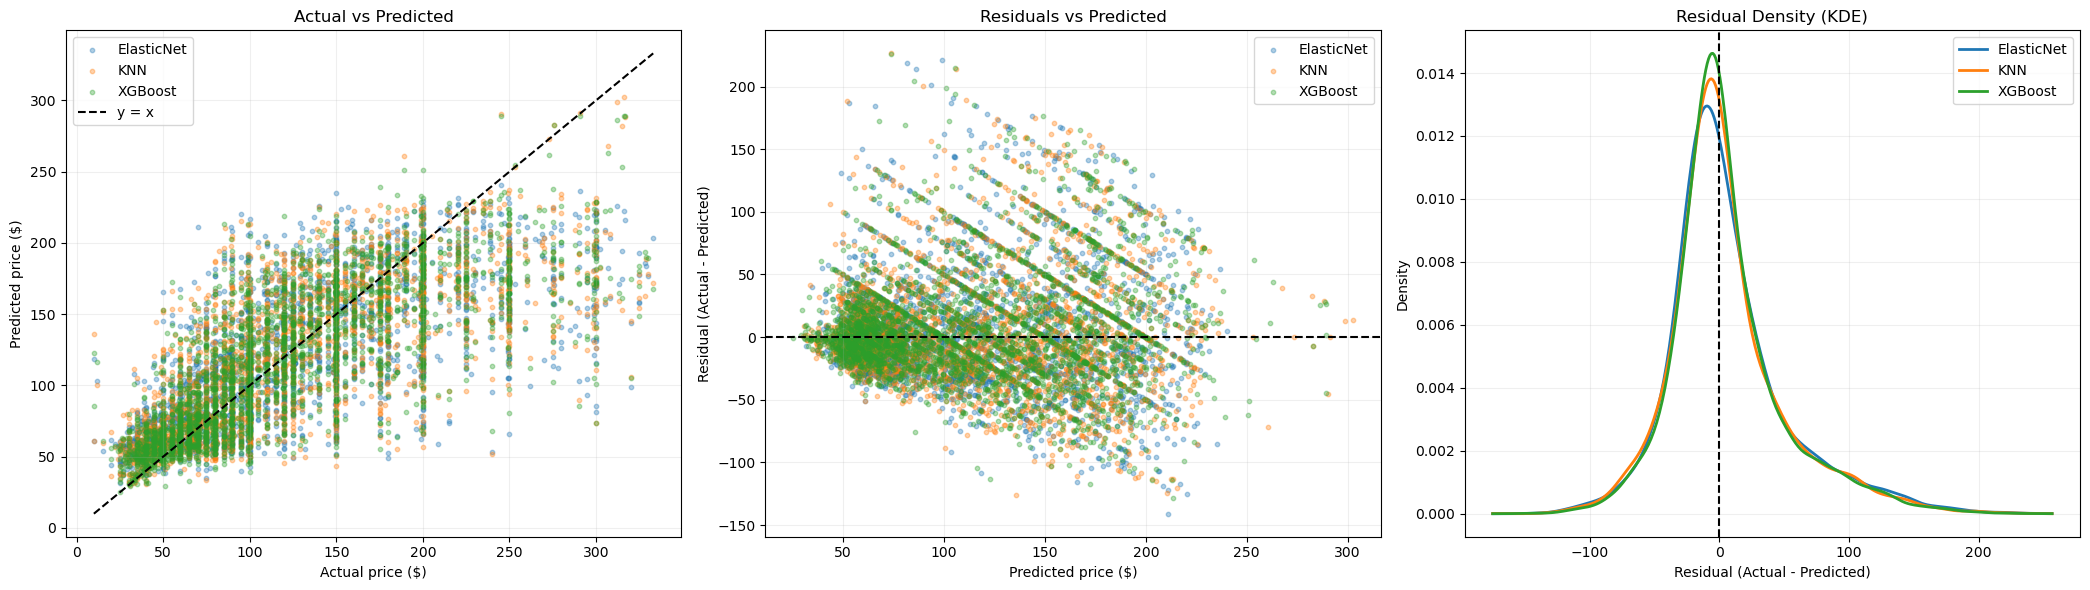

Metric being predicted: listing nightly price. Models are trained on log1p(price) and converted back to dollars for evaluation/plots.


In [7]:
# Diagnostic comparison plots: separate per-model charts for fit and residual behavior.
if "data" not in globals() or "elastic_result" not in globals():
    raise RuntimeError("Run the training cell first so model results and test data are available.")

import numpy as np
import matplotlib.pyplot as plt


def compute_gaussian_kde(values: np.ndarray, points: np.ndarray) -> np.ndarray:
    values_std = np.std(values)
    if values_std <= 0:
        return np.zeros_like(points)
    bandwidth = 1.06 * values_std * (len(values) ** (-1.0 / 5.0))
    if bandwidth <= 0:
        return np.zeros_like(points)
    scaled = (points[:, None] - values[None, :]) / bandwidth
    density = np.exp(-0.5 * scaled ** 2).sum(axis=1) / (len(values) * bandwidth * np.sqrt(2.0 * np.pi))
    return density


y_true_log = data.y_test.to_numpy(dtype=np.float64)
y_true_dollars = np.expm1(y_true_log)

predictions_log = {
    "ElasticNet": elastic_result.pipeline.predict(data.X_test),
    "KNN": knn_result.pipeline.predict(data.X_test),
    "XGBoost": xgb_result.pipeline.predict(data.X_test),
}

predictions_dollars = {
    model_name: np.expm1(predictions_log[model_name])
    for model_name in predictions_log
}

residuals = {
    model_name: y_true_dollars - predictions_dollars[model_name]
    for model_name in predictions_dollars
}

sample_size = min(3000, len(y_true_dollars))
rng = np.random.default_rng(config.RANDOM_STATE)
sample_indices = rng.choice(len(y_true_dollars), size=sample_size, replace=False)

identity_min = float(min(y_true_dollars.min(), *(p.min() for p in predictions_dollars.values())))
identity_max = float(max(y_true_dollars.max(), *(p.max() for p in predictions_dollars.values())))

# 1) Actual vs Predicted (3 separate graphs)
fig_actual, axes_actual = plt.subplots(1, 3, figsize=(21, 6), sharex=True, sharey=True)
for axis, (model_name, predicted) in zip(axes_actual, predictions_dollars.items()):
    axis.scatter(
        y_true_dollars[sample_indices],
        predicted[sample_indices],
        s=10,
        alpha=0.35,
        label=model_name,
    )
    axis.plot([identity_min, identity_max], [identity_min, identity_max], "k--", linewidth=1.5, label="y = x")
    axis.set_title(f"Actual vs Predicted - {model_name}")
    axis.set_xlabel("Actual price ($)")
    axis.grid(alpha=0.2)
    axis.legend()
axes_actual[0].set_ylabel("Predicted price ($)")
fig_actual.tight_layout()
plt.show()

# 2) Residuals vs Predicted (3 separate graphs)
fig_residual, axes_residual = plt.subplots(1, 3, figsize=(21, 6), sharey=True)
for axis, (model_name, predicted) in zip(axes_residual, predictions_dollars.items()):
    axis.scatter(
        predicted[sample_indices],
        residuals[model_name][sample_indices],
        s=10,
        alpha=0.35,
        label=model_name,
    )
    axis.axhline(0.0, color="black", linestyle="--", linewidth=1.5)
    axis.set_title(f"Residuals vs Predicted - {model_name}")
    axis.set_xlabel("Predicted price ($)")
    axis.grid(alpha=0.2)
    axis.legend()
axes_residual[0].set_ylabel("Residual (Actual - Predicted)")
fig_residual.tight_layout()
plt.show()

# 3) Residual density curves (all models on one graph)
fig_kde, axis_kde = plt.subplots(1, 1, figsize=(8, 6))
residual_min = float(min(values.min() for values in residuals.values()))
residual_max = float(max(values.max() for values in residuals.values()))
residual_axis = np.linspace(residual_min, residual_max, 400)
for model_name, model_residuals in residuals.items():
    density = compute_gaussian_kde(model_residuals.astype(np.float64), residual_axis)
    axis_kde.plot(residual_axis, density, linewidth=2.0, label=model_name)
axis_kde.axvline(0.0, color="black", linestyle="--", linewidth=1.5)
axis_kde.set_title("Residual Density (KDE)")
axis_kde.set_xlabel("Residual (Actual - Predicted)")
axis_kde.set_ylabel("Density")
axis_kde.grid(alpha=0.2)
axis_kde.legend()
fig_kde.tight_layout()
plt.show()

print("Metric being predicted: listing nightly price. Models are trained on log1p(price) and converted back to dollars for evaluation/plots.")